In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from pathlib import Path
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

train=[]
test=[]
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if 'train' in dirname: 
            train.append(Path(dirname)/filename)
        else:
            test.append(Path(dirname)/filename)


print(len(train))
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

5274


In [2]:
!pip install -Uqq fastai fastprogress

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.7/240.7 kB 5.5 MB/s eta 0:00:00


In [3]:
from fastai.vision.all import *

In [4]:
#Label function
def is_mal(x) : return x.parent.name

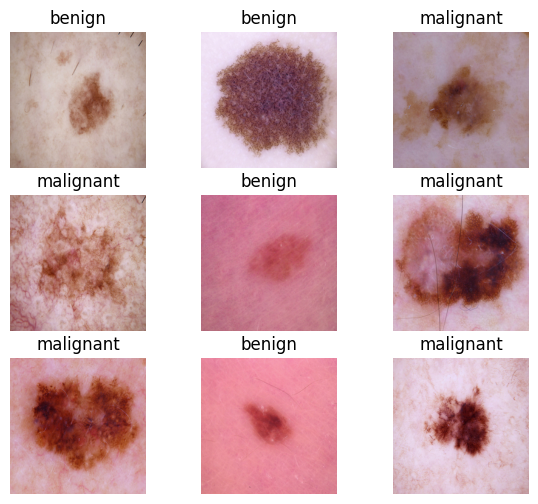

In [5]:
#Dataloders(These will give us a train and validation )
dls = ImageDataLoaders.from_path_func('.',
    train, label_func=is_mal, valid_pct=0.2, seed=42,
    )
dls.show_batch(max_n=9, figsize=(7,6))

In [6]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(4)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 196MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,0.581130,0.298307,0.125237,00:13


epoch,train_loss,valid_loss,error_rate,time
0,0.252863,0.126120,0.052182,00:08
1,0.118006,0.067497,0.026565,00:08
2,0.055153,0.049837,0.016129,00:08
3,0.026942,0.045491,0.011385,00:08


In [7]:
learn = vision_learner(dls, resnet152, metrics=error_rate)
learn.fine_tune(4)

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:00<00:00, 245MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,0.595087,0.416139,0.148956,00:39


epoch,train_loss,valid_loss,error_rate,time
0,0.241457,0.170922,0.059772,00:52
1,0.133215,0.076601,0.031309,00:52
2,0.062688,0.068862,0.025617,00:52
3,0.030072,0.068725,0.028463,00:52


In [8]:
learn.export('model.pkl')

In [9]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(12)

epoch,train_loss,valid_loss,error_rate,time
0,0.614644,0.305339,0.131879,00:06


epoch,train_loss,valid_loss,error_rate,time
0,0.292981,0.147585,0.058824,00:08
1,0.154841,0.079239,0.030361,00:08
2,0.082198,0.100713,0.030361,00:08
3,0.046723,0.100075,0.024668,00:08
4,0.038960,0.135148,0.027514,00:08
5,0.037057,0.093516,0.025617,00:08
6,0.028521,0.091906,0.018975,00:08
7,0.013874,0.073057,0.019924,00:08
8,0.007476,0.080684,0.018975,00:08
9,0.005551,0.066734,0.017078,00:08
